#### Project Title: Market Basket Analysis Using Apriori Algorithm
##### Student Name and Roll Number
	Name: Hussain Rasheed
    Roll Number: 1674
    Program: BS Computer Science
    College: Govt. Abdul Ali Khan College Utmanzai, Charsadda
###### Contact:
	Email:hussainrasheed632@gmail.com
##### Supervisor:
	Mr. Sakin Jan

##### Project Objective:
            The objective of this project is to perform Market Basket Analysis using the Apriori Algorithm. The project identifies products that are frequently purchased together and generates association rules based on support, confidence, and lift values. This helps businesses understand customer buying patterns and improve product placement and marketing strategies.

##### Machine Learning Algorithm(s) Used:
            Apriori Algorithm:
                    Used to find frequent itemsets in transaction data.

            Association Rule Mining:
                Used to generate relationships between products using:
                1. Support
                2. Confidence
                3. Lift
##### Dataset:
1. Grocery Transaction Dataset
2. 1000 Transactions
3. 	Each row represents one customer transaction
4. Dataset source: [kaggle Grocery dataset] ("https://www.kaggle.com/datasets/hussainprogrammer/grocery-dataset")

##### Required Libraries:
        Required packages:
                1. Pandas
                2. Matplotlib
                3.Mlxtend

##### Instructions to Run the Project:
                1. Install all required libraries.
                2. Place grocery_dataset.csv in the same folder as the notebook.
                3. Open the Jupyter Notebook.
                4. Run all cells from top to bottom.
                5. The program will:
                        Load the dataset.
                        Convert transactions into binary format.
                        Apply the Apriori Algorithm.
                        Generate association rules.
                        Display the strongest product relationships using a graph.
        
##### Expected Output/Results:
            The project will:
                Display frequent itemsets.
                Generate association rules between products.
                Calculate support, confidence, and lift values.
                Identify products that are commonly purchased together.
                Show a bar chart of the top association rules ranked by lift.
##### Supervisor Acknowledgment:
	I would like to express my sincere gratitude to Mr. Sakin Jan for his valuable guidance and support throughout this project.


### 1. Import Libraries
1. Pandas:
        Pandas Library used for file Handling 
        DataFrame and Series is data Structure of Pandas.
2. mlxtend:
        Python library used for machine learning and data science.
        full name is Machine Learning Extensions.
        ---> It Provides Extra Tools that are not directly available in scikit-learn.
3. TransactionEncoder:
       converts transaction data into binary format
4. Apriori and association rules are used for market basket analysis.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

### 2. Load Dataset
            Header= None used because dataset have no column names

In [2]:
df = pd.read_csv("grocery_dataset.csv", header= None) 

df.head() # show first five transactions

,0
0,"Chips, Flour"
1,"Soap, Flour, Shampoo"
2,"Noodles, Coffee"
3,"Eggs, Biscuits"
4,"Shampoo, Biscuits, Ice Cream, Cooking Oil, Bre..."


### 3. Convert dataset rows into Transaction List:
                        The Dataset is converted into lists format.
                        Each rows become one transactions.
                        Empty values are removed.
                        This format is required for Apriori Algorithm

In [3]:
transactions = []

for i in range(len(df)):
    row = str(df.values[i, 0]).split(',')
    row = [item.strip() for item in row if item != 'nan']
    transactions.append(row)

In [4]:
print(transactions[0:5])

[['Chips', 'Flour'], ['Soap', 'Flour', 'Shampoo'], ['Noodles', 'Coffee'], ['Eggs', 'Biscuits'], ['Shampoo', 'Biscuits', 'Ice Cream', 'Cooking Oil', 'Bread', 'Flour', 'Noodles']]


### 4. Data Preprocessing:
            Transaction Data is converted into Binary format.
            True = item exists
            False = item does not exist.
            Apriori Algorithm works on Binary Data.

In [5]:
te = TransactionEncoder()

# Convert transactions into Binary Format
te_data = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_data, columns=te.columns_) # create DataFrame 

basket.head() # Show first five rows

,Apples,Bananas,Beef,Biscuits,Bread,Butter,Cheese,Chicken,Chips,Coffee,...,Potatoes,Rice,Salt,Shampoo,Soap,Sugar,Tea,Tomatoes,Toothpaste,Yogurt
0,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


### 5. Apply Apriori Algorithm:
        The Apriori Algorithm is used to find frequent itemsets.
        min_support = 0.03 means item must appear in at least 3% transactions.
        use_colnames = True. Display actual item names.

In [6]:
frequent_itemsets= apriori(basket, min_support=0.03, use_colnames = True)

# 1000 * 0.03 = 30 item combination must appear at least 30 times 

In [7]:
print("Frequent Itemsets:")

print(frequent_itemsets.head())

Frequent Itemsets:
   support               itemsets
0    0.160    frozenset({Apples})
1    0.180   frozenset({Bananas})
2    0.161      frozenset({Beef})
3    0.177  frozenset({Biscuits})
4    0.167     frozenset({Bread})


### 6. Generate Association Rules:
        Association Rules are generated using confidence values.
        antecedents = first item
        consequents = related item 
        support = frequency
        confidence = probability 
        lift = relationship strength

In [8]:
rules = association_rules(frequent_itemsets, metric= "confidence", min_threshold = 0.2)

# min_threshold = 0.2 means the minimum confidence required for association rules is 20%

print("Association Rules:")
print(rules[['antecedents','consequents','support','confidence','lift']])

Association Rules:
             antecedents              consequents  support  confidence  \
0    frozenset({Apples})      frozenset({Cheese})    0.035    0.218750   
1    frozenset({Apples})        frozenset({Milk})    0.032    0.200000   
2    frozenset({Apples})       frozenset({Pasta})    0.033    0.206250   
3    frozenset({Apples})        frozenset({Rice})    0.032    0.200000   
4    frozenset({Apples})     frozenset({Shampoo})    0.032    0.200000   
..                   ...                      ...      ...         ...   
105   frozenset({Sugar})     frozenset({Shampoo})    0.034    0.202381   
106   frozenset({Sugar})         frozenset({Tea})    0.034    0.202381   
107     frozenset({Tea})       frozenset({Sugar})    0.034    0.215190   
108   frozenset({Sugar})  frozenset({Toothpaste})    0.034    0.202381   
109  frozenset({Yogurt})  frozenset({Toothpaste})    0.035    0.200000   

         lift  
0    1.195355  
1    1.204819  
2    1.213235  
3    1.183432  
4    1.11111

#### support = 0.035 = 3.5%
             mean Apples and cheese appeared together in 3.5% transactions
### confidence = 21.87 = 21.8%
                21.8% customers buying apples also cheese

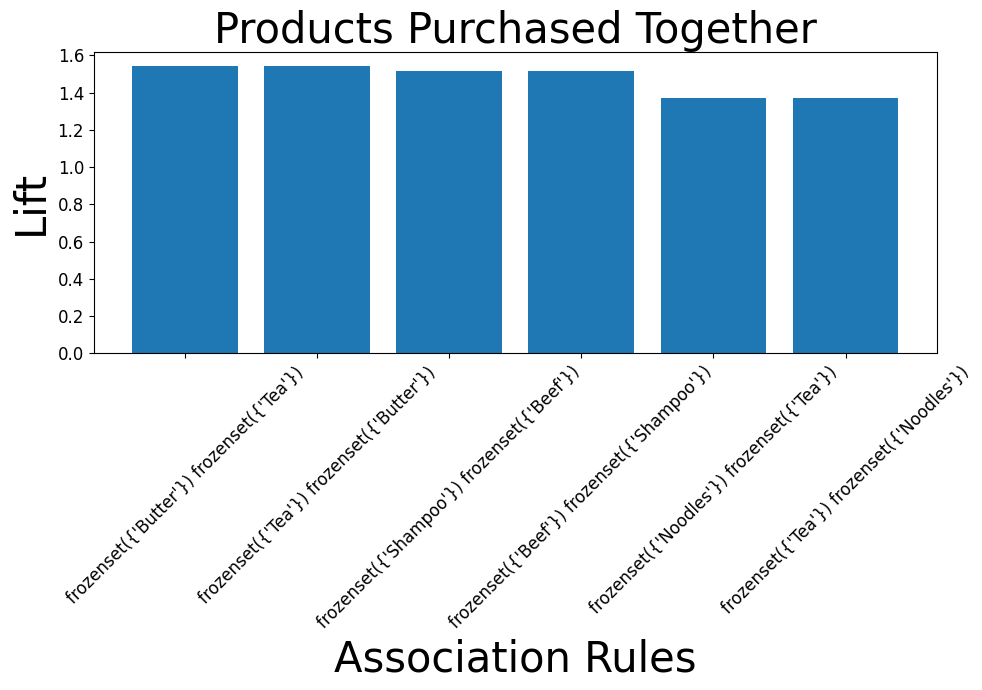

In [11]:
# sort Top frequent items

top_rules = rules.sort_values(by = 'lift', ascending = False).head(6)

# Create Labels
labels = top_rules['antecedents'].astype(str)+" "+ top_rules['consequents'].astype(str)

plt.figure(figsize=(10,7))

plt.bar(labels, top_rules['lift'])

plt.title("Products Purchased Together", fontsize = 30)

plt.xlabel("Association Rules", fontsize = 30)

plt.ylabel("Lift", fontsize = 30)

plt.xticks(rotation = 45, fontsize=12)

plt.yticks(fontsize =12)

plt.tight_layout()
plt.show()
